<a href="https://colab.research.google.com/github/KomarevtsevER/project_Komarevtsev/blob/master/IIS_Lr1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pickle

In [ ]:
df = pd.read_csv('train.csv')

In [ ]:
df.head(10)

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,2,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,6,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,6,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,9,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,14,1208,1212,1411,8,2,15,1,1,0,1
5,1859,0,0.5,1,3,0,22,0.7,164,1,7,1004,1654,1067,17,1,10,1,0,0,1
6,1821,0,1.7,0,4,1,10,0.8,139,8,10,381,1018,3220,13,8,18,1,0,1,3
7,1954,0,0.5,1,0,0,24,0.8,187,4,0,512,1149,700,16,3,5,1,1,1,0
8,1445,1,0.5,0,0,0,53,0.7,174,7,14,386,836,1099,17,1,20,1,0,0,0
9,509,1,0.6,1,2,1,9,0.1,93,5,15,1137,1224,513,19,10,12,1,0,0,0


In [ ]:
df.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int64  
 18  touch_sc

In [ ]:
categorical_cols = ['blue', 'dual_sim', 'four_g', 'three_g', 'touch_screen', 'wifi', 'n_cores']
df[categorical_cols] = df[categorical_cols].astype('category')


In [ ]:
df['pc'] = df['pc'].astype('int8')
df['fc'] = df['fc'].astype('int8')
df['int_memory'] = df['int_memory'].astype('int8')
df['sc_h'] = df['sc_h'].astype('int8')
df['sc_w'] = df['sc_w'].astype('int8')
df['talk_time'] = df['talk_time'].astype('int8')
df['price_range'] = df['price_range'].astype('int8')

df['mobile_wt'] = df['mobile_wt'].astype('int16')
df['battery_power'] = df['battery_power'].astype('int16')
df['px_height'] = df['px_height'].astype('int16')
df['px_width'] = df['px_width'].astype('int16')
df['ram'] = df['ram'].astype('int16')


df['clock_speed'] = df['clock_speed'].astype('float32')
df['m_dep'] = df['m_dep'].astype('float32')


In [ ]:
df.describe()

,battery_power,clock_speed,fc,int_memory,m_dep,mobile_wt,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,price_range
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1238.518500,1.522250,4.309500,32.046500,0.501750,140.249000,9.916500,645.108000,1251.515500,2124.213000,12.306500,5.767000,11.011000,1.500000
std,439.418206,0.816006,4.341444,18.145715,0.288415,35.399655,6.064315,443.780811,432.199447,1084.732044,4.213245,4.356398,5.463955,1.118314
min,501.000000,0.500000,0.000000,2.000000,0.100000,80.000000,0.000000,0.000000,500.000000,256.000000,5.000000,0.000000,2.000000,0.000000
25%,851.750000,0.700000,1.000000,16.000000,0.200000,109.000000,5.000000,282.750000,874.750000,1207.500000,9.000000,2.000000,6.000000,0.750000
50%,1226.000000,1.500000,3.000000,32.000000,0.500000,141.000000,10.000000,564.000000,1247.000000,2146.500000,12.000000,5.000000,11.000000,1.500000
75%,1615.250000,2.200000,7.000000,48.000000,0.800000,170.000000,15.000000,947.250000,1633.000000,3064.500000,16.000000,9.000000,16.000000,2.250000
max,1998.000000,3.000000,19.000000,64.000000,1.000000,200.000000,20.000000,1960.000000,1998.000000,3998.000000,19.000000,18.000000,20.000000,3.000000


In [ ]:
cat_features = df.select_dtypes(include=['category']).columns.to_list()
cat_features

['blue', 'dual_sim', 'four_g', 'n_cores', 'three_g', 'touch_screen', 'wifi']

In [ ]:
num_features = df.select_dtypes(include=['number']).columns.to_list()
num_features

['battery_power',
 'clock_speed',
 'fc',
 'int_memory',
 'm_dep',
 'mobile_wt',
 'pc',
 'px_height',
 'px_width',
 'ram',
 'sc_h',
 'sc_w',
 'talk_time',
 'price_range']

In [ ]:
df.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   battery_power  2000 non-null   int16   
 1   blue           2000 non-null   category
 2   clock_speed    2000 non-null   float32 
 3   dual_sim       2000 non-null   category
 4   fc             2000 non-null   int8    
 5   four_g         2000 non-null   category
 6   int_memory     2000 non-null   int8    
 7   m_dep          2000 non-null   float32 
 8   mobile_wt      2000 non-null   int16   
 9   n_cores        2000 non-null   category
 10  pc             2000 non-null   int8    
 11  px_height      2000 non-null   int16   
 12  px_width       2000 non-null   int16   
 13  ram            2000 non-null   int16   
 14  sc_h           2000 non-null   int8    
 15  sc_w           2000 non-null   int8    
 16  talk_time      2000 non-null   int8    
 17  three_g        2000 non-null   ca

In [ ]:
for cat in cat_features:
    print(f'{cat} - numer of unique = {df[cat].nunique()}')

blue - numer of unique = 2
dual_sim - numer of unique = 2
four_g - numer of unique = 2
n_cores - numer of unique = 8
three_g - numer of unique = 2
touch_screen - numer of unique = 2
wifi - numer of unique = 2


In [ ]:
for col in cat_features:
    print(f'Unique categories in {col}: {df[col].value_counts()}')

Unique categories in blue: blue
0    1010
1     990
Name: count, dtype: int64
Unique categories in dual_sim: dual_sim
1    1019
0     981
Name: count, dtype: int64
Unique categories in four_g: four_g
1    1043
0     957
Name: count, dtype: int64
Unique categories in n_cores: n_cores
4    274
7    259
8    256
2    247
5    246
3    246
1    242
6    230
Name: count, dtype: int64
Unique categories in three_g: three_g
1    1523
0     477
Name: count, dtype: int64
Unique categories in touch_screen: touch_screen
1    1006
0     994
Name: count, dtype: int64
Unique categories in wifi: wifi
1    1014
0     986
Name: count, dtype: int64


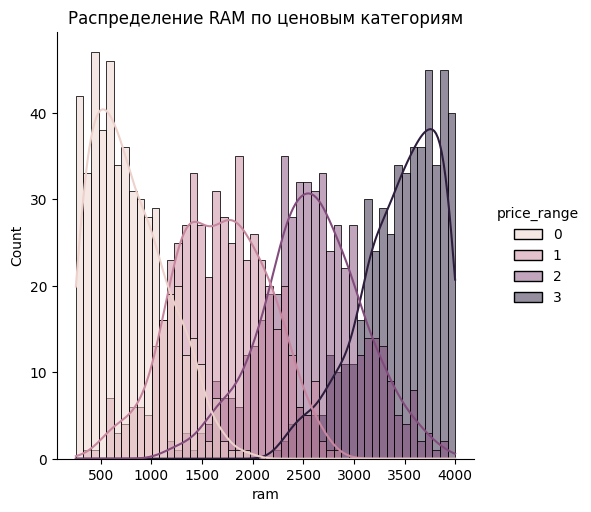

In [ ]:
sns.displot(df, x='ram', bins=50, hue='price_range', kde=True)
plt.title('Распределение RAM по ценовым категориям')
plt.show()

In [ ]:
# Общее разрешение экрана (площадь в пикселях)
df['total_pixels'] = df['px_height'].astype('int32') * df['px_width'].astype('int32')

# Плотность пикселей (примерная)
df['pixel_density'] = df['total_pixels'] / (df['sc_h'].astype('float32') * df['sc_w'].astype('float32'))

# Эффективность батареи (батарея на грамм веса)
df['battery_efficiency'] = df['battery_power'].astype('float32') / df['mobile_wt'].astype('float32')

# Общая мощность камер
df['total_camera'] = df['pc'] + df['fc']



In [ ]:
import importlib
importlib.reload(sns)

<module 'seaborn' from '/usr/local/lib/python3.13/dist-packages/seaborn/__init__.py'>

In [ ]:
print(type(sns))
print(sns.__file__)

<class 'module'>
/usr/local/lib/python3.13/dist-packages/seaborn/__init__.py


In [ ]:
!pip uninstall seaborn -y
!pip install seaborn

Found existing installation: seaborn 0.13.2
Uninstalling seaborn-0.13.2:
  Successfully uninstalled seaborn-0.13.2
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)


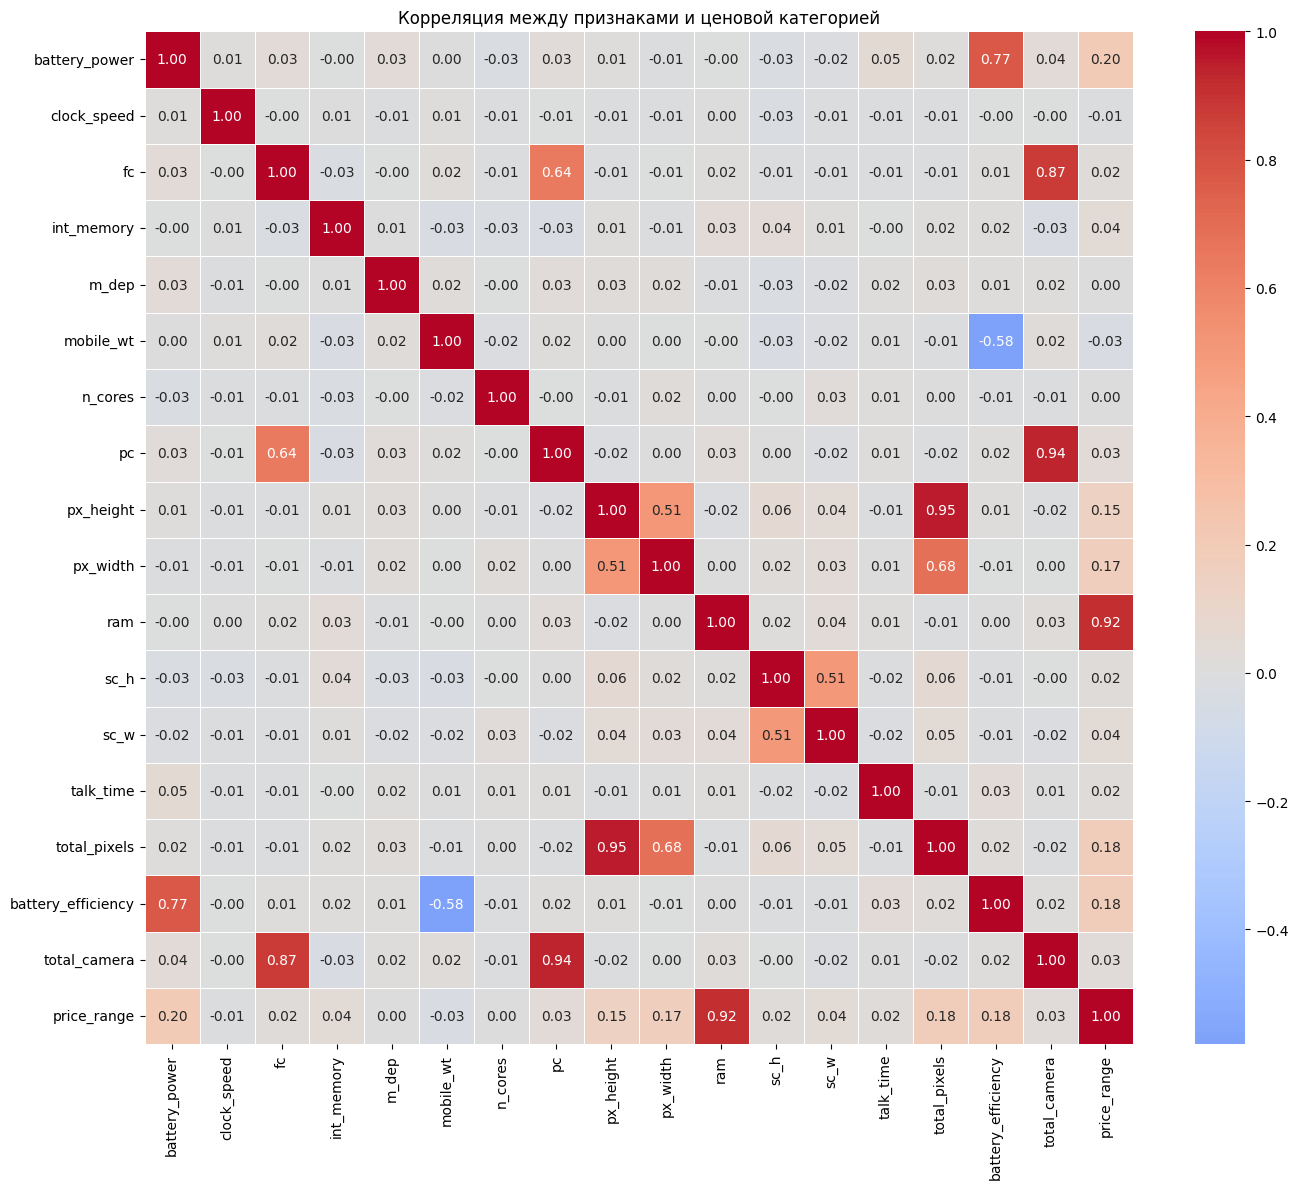

In [ ]:
# Выбираем числовые признаки
num_features = ['battery_power', 'clock_speed', 'fc', 'int_memory',
                'm_dep', 'mobile_wt', 'n_cores', 'pc', 'px_height',
                'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time',
                'total_pixels',  'battery_efficiency',
                'total_camera']

# Вычисляем корреляционную матрицу
feature_correlation = df[num_features + ['price_range']].corr()

# Визуализируем heatmap
plt.figure(figsize=(14, 12))
sns.heatmap(feature_correlation, annot=True, cmap='coolwarm',
            linewidths=0.5, fmt='.2f', center=0)
plt.title('Корреляция между признаками и ценовой категорией')
plt.tight_layout()
plt.show()

In [ ]:
pd.set_option('display.max_columns', None)

In [ ]:
# Выбираем только числовые признаки (исключаем категориальные)
num_features = ['battery_power', 'clock_speed', 'fc', 'int_memory',
                'm_dep', 'mobile_wt', 'pc', 'px_height',
                'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time',
                'total_pixels', 'battery_efficiency', 'total_camera']
# ← убрали 'n_cores', так как он category

# Группируем
aggregated_df = df[num_features + ['price_range']].groupby(
    by='price_range'
).agg(['mean', 'std'])

aggregated_df = flat_index(aggregated_df)
aggregated_df

,price_range,battery_power_mean,battery_power_std,clock_speed_mean,clock_speed_std,fc_mean,fc_std,int_memory_mean,int_memory_std,m_dep_mean,m_dep_std,mobile_wt_mean,mobile_wt_std,pc_mean,pc_std,px_height_mean,px_height_std,px_width_mean,px_width_std,ram_mean,ram_std,sc_h_mean,sc_h_std,sc_w_mean,sc_w_std,talk_time_mean,talk_time_std,total_pixels_mean,total_pixels_std,battery_efficiency_mean,battery_efficiency_std,total_camera_mean,total_camera_std
0,0,1116.902,410.801305,1.5502,0.848941,4.084,4.183772,31.174,18.101023,0.4902,0.288184,140.552,36.378319,9.574,6.095805,536.408,372.824164,1150.270,413.001780,785.314,362.755397,12.324,4.206949,5.682,4.174173,10.612,5.397009,678837.798,636007.252658,8.537833,4.042089,13.658,9.283394
1,1,1228.868,438.614528,1.4886,0.814479,4.340,4.499432,32.116,18.000739,0.5240,0.286895,140.510,35.678956,9.924,6.124806,666.892,441.351209,1251.908,433.564352,1679.490,465.850159,12.212,4.226913,5.544,4.238868,11.362,5.570729,930234.068,831493.965929,9.272803,4.021695,14.264,9.693412
2,2,1228.320,452.863065,1.5298,0.804404,4.498,4.347390,30.920,18.441958,0.4908,0.286215,143.614,34.320326,10.018,5.952861,632.284,445.789232,1234.046,427.757151,2582.816,496.211735,12.010,4.234355,5.714,4.265747,10.972,5.433070,880749.466,828484.680477,9.190834,4.426488,14.516,9.428443
3,3,1379.984,414.992261,1.5204,0.796450,4.316,4.332399,33.976,17.930377,0.5020,0.291901,136.320,34.911994,10.150,6.085521,744.848,483.720179,1369.838,426.823571,3449.232,393.019923,12.680,4.168976,6.128,4.716790,11.098,5.443129,1131218.882,933879.970354,10.832832,4.364662,14.466,9.449626


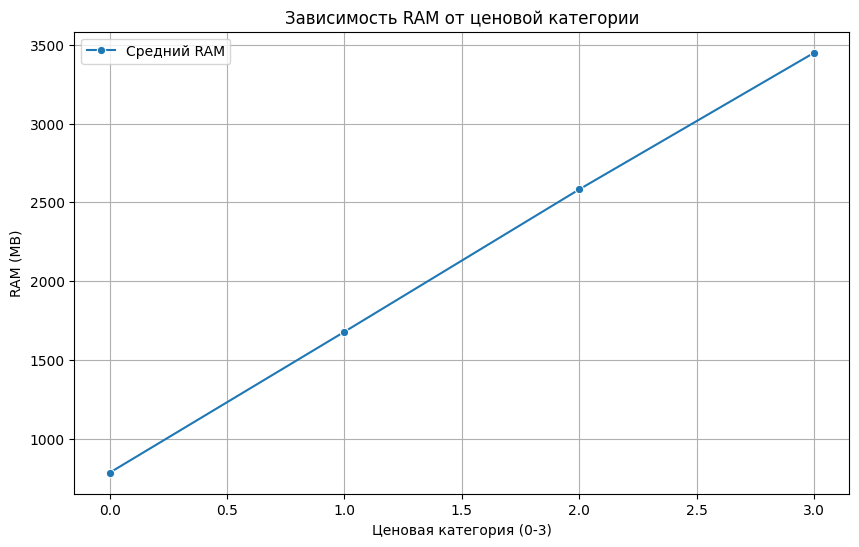

In [ ]:
# График среднего RAM по ценовым категориям
plt.figure(figsize=(10, 6))
sns.lineplot(aggregated_df, x='price_range', y='ram_mean',
             label='Средний RAM', marker='o')
plt.title('Зависимость RAM от ценовой категории')
plt.xlabel('Ценовая категория (0-3)')
plt.ylabel('RAM (MB)')
plt.grid(True)
plt.show()

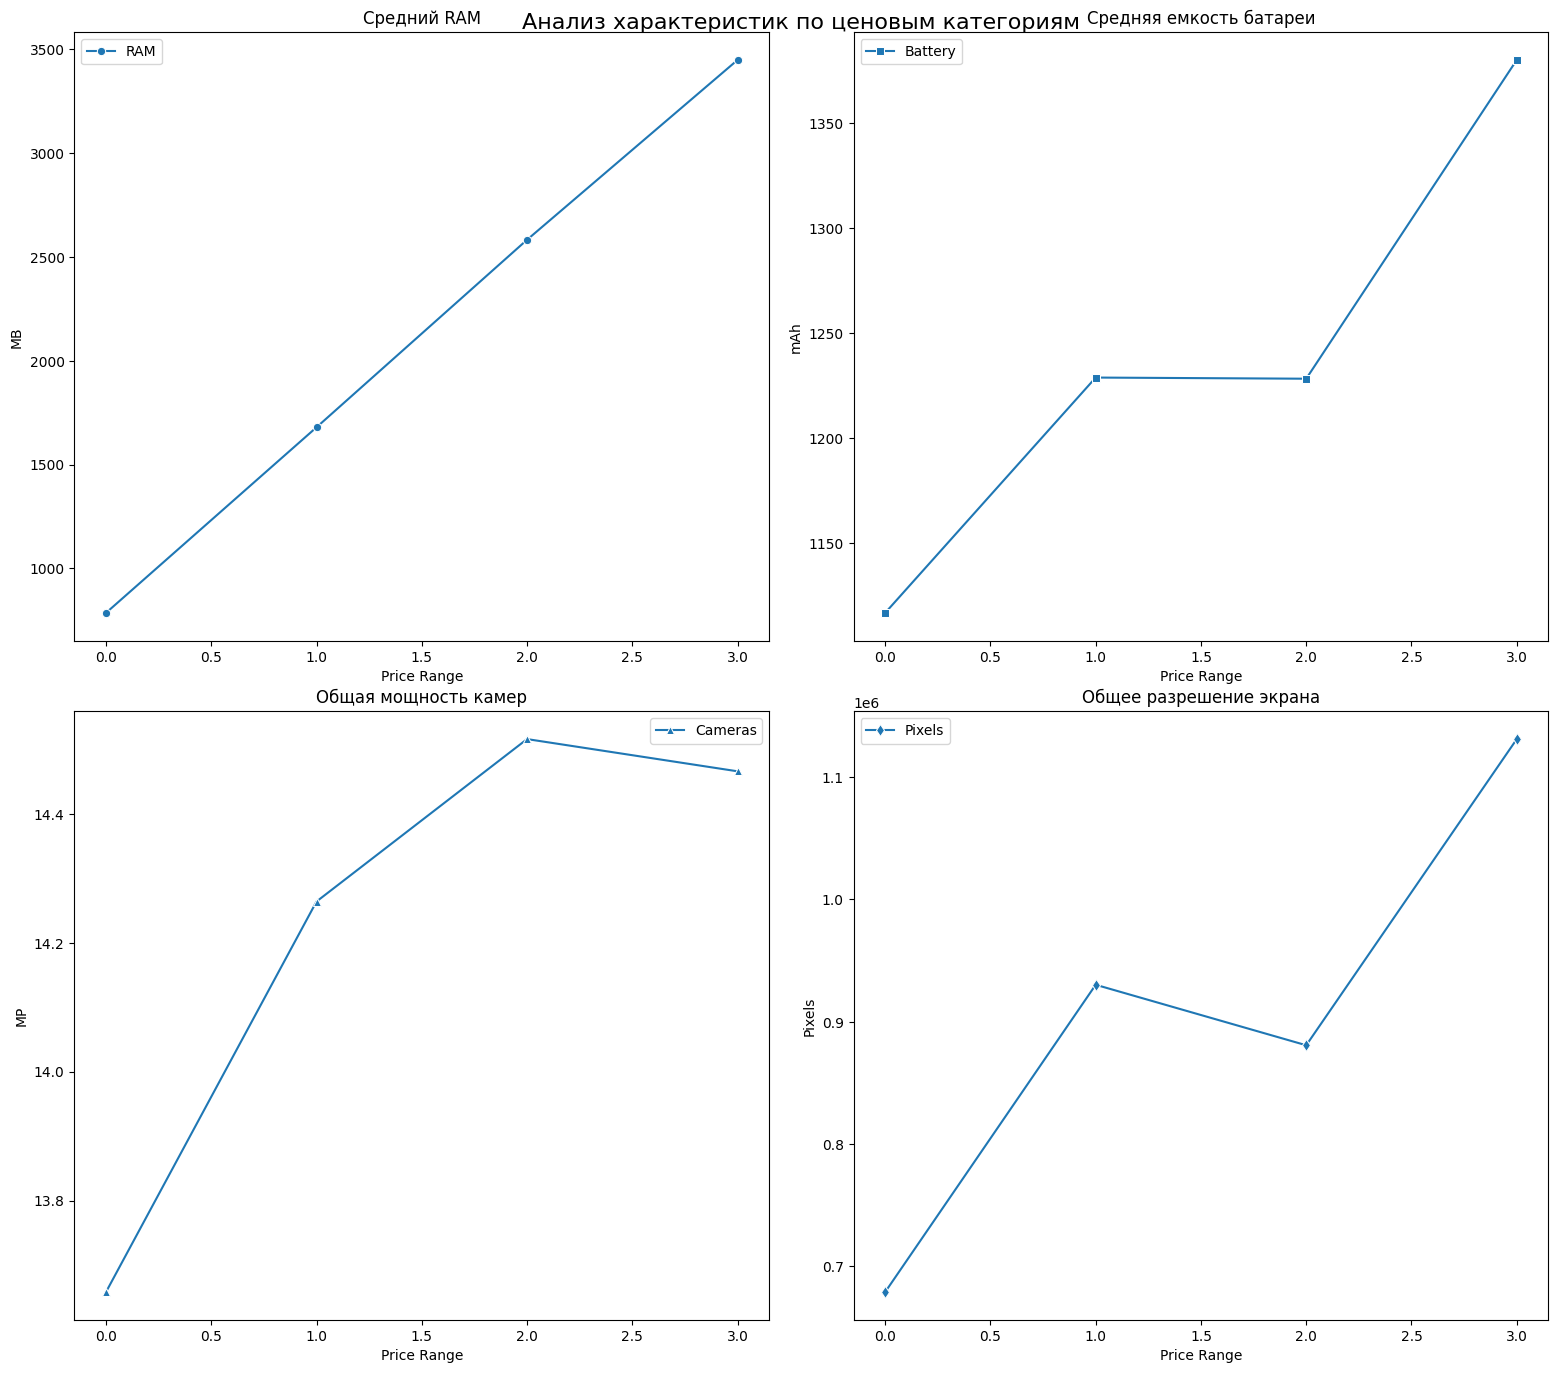

In [ ]:
# Создаем сетку 2x2 графиков
fig, axs = plt.subplots(2, 2, figsize=(16, 14))
fig.tight_layout(pad=3)
fig.suptitle('Анализ характеристик по ценовым категориям', fontsize=16)

# График 1: RAM
sns.lineplot(aggregated_df, x='price_range', y='ram_mean',
             label='RAM', ax=axs[0,0], marker='o')
axs[0,0].set_title('Средний RAM')
axs[0,0].set_xlabel('Price Range')
axs[0,0].set_ylabel('MB')

# График 2: Батарея
sns.lineplot(aggregated_df, x='price_range', y='battery_power_mean',
             label='Battery', ax=axs[0,1], marker='s')
axs[0,1].set_title('Средняя емкость батареи')
axs[0,1].set_xlabel('Price Range')
axs[0,1].set_ylabel('mAh')

# График 3: Камеры
sns.lineplot(aggregated_df, x='price_range', y='total_camera_mean',
             label='Cameras', ax=axs[1,0], marker='^')
axs[1,0].set_title('Общая мощность камер')
axs[1,0].set_xlabel('Price Range')
axs[1,0].set_ylabel('MP')

# График 4: Разрешение экрана
sns.lineplot(aggregated_df, x='price_range', y='total_pixels_mean',
             label='Pixels', ax=axs[1,1], marker='d')
axs[1,1].set_title('Общее разрешение экрана')
axs[1,1].set_xlabel('Price Range')
axs[1,1].set_ylabel('Pixels')

plt.show()

In [ ]:
from bokeh.plotting import figure, show
from bokeh.models import ColumnDataSource, HoverTool
from bokeh.io import output_notebook
from bokeh.transform import factor_cmap

output_notebook()

# Берем случайную выборку для скорости
source = ColumnDataSource(data=df.sample(frac=0.1, random_state=42))

# Создаем интерактивный scatter plot
p = figure(width=800, height=600,
           title="RAM vs Battery Power ")

# Добавляем точки с цветом по price_range
scatter = p.scatter(source=source, x='ram', y='battery_power',
                    color=factor_cmap('price_range', 'Category10_4',
                                     ['0', '1', '2', '3']),
                    size=8, alpha=0.6)

# Добавляем подсказки при наведении
hover = HoverTool(tooltips=[
    ('RAM', '@ram MB'),
    ('Battery', '@battery_power mAh'),
    ('Price Range', '@price_range'),
    ('Cores', '@n_cores')
])

p.add_tools(hover)
p.xaxis.axis_label = 'RAM (MB)'
p.yaxis.axis_label = 'Battery Power (mAh)'

show(p)

In [ ]:
df.to_pickle('./data/clean_train.pkl')